# Changes in exposure to extreme heat and its impacts in New York City: a hands-on exercise

As we talked about in lecture today, the most common form of localized, numerical information about future climate conditions comes from GCMs, though that information is subject to uncertainty from internal variability, model uncertainty, and scenario uncertainty. Another wrinkle comes from the fact that GCMs are not perfect representations of the real world, and we can't directly interpret their output as we would, say, read a thermometer. Thus, GCMs are "bias-corrected" before being used in climate impacts contexts - we train a *bias-correction* over some period where we expect the GCMs and the real world to be comparable (say, the last few decades where we have direct observations to compare the models to), and apply that correction to future projections. 

**In this hands-on exercise, we're going to get a sense of what working with GCM output looks like in the context of a real-world problem (heat exposure in New York City), and get you familiar with thinking about the influence of these sources of uncertainty when thinking about projections of climate risks.** In a bit of a whirlwind tour of working with climate data, we will: 

1. Look at projections of temperature change in the Northeast US at the regional level
2. Analyze projections of exposure to extreme temperature in New York City
3. Use a sample "damage function" to translate that exposure into possible changes in heat-related mortality

We'll be using the [BCD-ME](https://app.earthmover.io/marketplace/696aaa41490a002f0d47b8a1?tab=dataset&path=CESM2-WACCM) (the "Bias-Corrected and Downscled Massive Ensemble"), which is a collection of daily mean and maximum temperature from CMIP6 GCMs (developed by myself and a few co-authors, including Prof. Horton), bias-corrected and downscaled to different reanalysis products. We designed it to specifically sample internal variability and test the consequences of the choice of "ground-truth" dataset used for bias-correction and downscaling, in addition to sampling model uncertainty. A quirk of the dataset is that the data is provided by Global Warming Level instead of by year (if you're interested, you can see some of our justification for this in [this preprint](https://eartharxiv.org/repository/view/11902/)). A Global Warming Level (GWL) refers to the change in Global Mean Surface Temperature (in Kelvin or, equivalently, degrees Celsius) over some reference period, commonly taken to be 1850-1900. The Paris Agreement, for example, was built on GWLs: 2 degrees, or 1.5 degrees if possible. For each GWL, we show 20 years of data centered around when the real world or a GCM warms that amount on average. Showing data by GWL means that we've controlled for scenario uncertainty, and we remove one source of model uncertainty (stemming from the relative speed of warming).  

A benefit of the BCD-ME for the purposes of this exercise is that you can access data in a preprocessed format through your own computer and this jupyter notebook, without having to access the raw GCM output and bias-correct or downscale it yourself. It's not the only dataset of its kind out there - others use different bias-correction or downscaling methodologies (such as [Carbon Plan's products](https://carbonplan.org/research/cmip6-downscaling-explainer), for example, or provide data as continuous time series instead (such as the [NASA NEX-GDDP](https://www.nccs.nasa.gov/services/data-collections/land-based-products/nex-gddp) or [GDPCIR](https://planetarycomputer.microsoft.com/dataset/group/cil-gdpcir/) datasets). 

You do not need to know `python` to work your way through this exercise, though some knowledge of it may make experimenting with the data easier. Pressing shift-enter will run each "cell" of Jupyter Notebook below. "#" is the comment symbol for python; the code ignores anything written after a # on a given line.

**One warning, however** : the full BCD-ME is 100 TB, and it is theoretically possible to request a download of the entire dataset (and likely, if temporarily, crash your computer) if you modify the code below too much. Nothing is loaded onto your computer until you run code that looks like this: `ds.load()`, and this Notebook is set up currently such that only ever a small amount of data (on the order of MBs) is loaded at a time. If you modify the code to experiment with the data--and you are encouraged to!--make sure you're working with a reasonable amount of data. Type `print(ds)` (replacing `ds` with the name of your dataset) into an empty cell and run it, and it will show you its size, if loaded, at the top. 

#### Questions to answer
Please aim to come up with answers to questions 1.1 - 1.3, 2.1 - 2.5, and 3.1 - 3.3 listed below. I've added some other optional questions designed to get you to think more deeply about the data, these are numbered 1x.#, 2x.#, and so forth. 

In [259]:
# Load required packages. You've installed these when creating the environment, 
# so as long as you're running `jupyter lab` from a bash window that you have 
# first loaded the `bcd_me` environment (with "conda activate bcd_me") in, these
# will load

import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
from arraylake import Client
import zarr
import warnings

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib import patches as mpatches
import cartopy
from cartopy import crs as ccrs
import cmocean

## Setup

The BCD-ME is currently stored on Earthmover's Marketplace, which is a cloud store of gridded data products. Earthmover is a startup run by many of the core developers of the primary tools used in python-based climate work (xarray, the zarr data format, e.g.). 

A (free) Earthmover account is necessary to access the data. You can sign up at [earthmover.io](earthmover.io) with Github, Google, or email.

Once signed up, authenticate in the notebook:

In [346]:
# Start ArrayLake client
client = Client()

#authenticate sign-up for Earthmover:
client.login(browser=False)  


Successfully refreshed tokens! Token stored at /Users/kevinschwarzwald/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: ks3753@columbia.edu                                                                                      │
│ Id: eed8e278-d956-43f1-aa47-8472019241ef                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 1. Diagnostics of mean temperature changes (using a single GCM)

The first thing we will do is get a basic sense of projected changes in mean temperature over the northeast US under climate change, as projected by GCMs. We will do this by accessing the BCD-ME's 1-degree-resolution timeseries of mean daily temperature. 1 x 1 degree is roughly the spatial scale of most CMIP-class GCMs (for ease of comparison, each GCM's data has been "regridded" to the uniform 1-degree grid).

We'll start off with analyzing data from one GCM - looking at the regional change in temperature from GWL0.61 (which is equivalent to the late 20th century - the average over 1982-2001, to be exact) to GWL2 (the world envisioned by the Paris Agreement). 

As you step through the notebook cells below, the code will access temperature data from a GCM, subset it to the northeast, take the 20-year average of it, and plot these changes as maps. 

In [347]:
# Start session to access 1-deg bias-corrected data
repo = client.get_repo("ClimateUncertaintyLab/bcd_me_qdm")
session = repo.readonly_session(branch="main")

# Get list of available GCMs
modlist = np.sort(list(zarr.open_group(session.store,mode='r').group_keys()))

# there's currently a bug with the data for the GCM EC-Earth3, so I'm going to remove it: 
modlist = [mod for mod in modlist if mod != 'EC-Earth3']

print(f'Available GCMs: {', '.join(modlist)}')

Available GCMs: ACCESS-ESM1-5, CESM2-WACCM, CNRM-CM6-1, CNRM-ESM2-1, CanESM5, EC-Earth3, EC-Earth3-Veg, FGOALS-g3, IPSL-CM6A-LR, MIROC6, MPI-ESM1-2-LR, MRI-ESM2-0


In [359]:
# Open one model's worth of data 
mod = 'CESM2-WACCM'
print(f'Opening {mod}')
ds = xr.open_zarr(session.store, zarr_format=3, group=mod)
# We're calling the dataset "ds", which is a common default name 
# for climate data analysis using the xarray (xr) package

Opening CESM2-WACCM


Let's see what this dataset looks like under the hood, by printing the metadata of the dataset below:

In [360]:
ds

<xarray.Dataset> Size: 764GB
Dimensions:        (idv: 8, proj_base: 4, lat: 142, lon: 360, gwl: 8,
                    dayofyear: 365, year: 20, variable: 1)
Coordinates:
    experiment     (idv) <U6 192B dask.array<chunksize=(8,), meta=np.ndarray>
    model          (idv) <U11 352B dask.array<chunksize=(8,), meta=np.ndarray>
    run            (idv) <U8 256B dask.array<chunksize=(8,), meta=np.ndarray>
  * proj_base      (proj_base) <U6 96B 'ERA5' 'GMFD' 'JRA-3Q' 'MERRA2'
  * lat            (lat) float64 1kB -55.5 -54.5 -53.5 -52.5 ... 83.5 84.5 85.5
  * lon            (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * gwl            (gwl) float64 64B 0.61 1.0 1.5 2.0 2.5 3.0 3.5 4.0
    has_data       (variable, idv, gwl) bool 64B dask.array<chunksize=(1, 8, 8), meta=np.ndarray>
  * dayofyear      (dayofyear) int64 3kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
  * year           (year) int64 160B 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    calendar_year  (idv, gwl, year) float64 10kB dask.array<chunksize=(8, 8, 20), meta=np.ndarray>
  * variable       (variable) object 8B 'tas'
Dimensions without coordinates: idv
Data variables:
    tas            (idv, proj_base, lat, lon, gwl, dayofyear, year) float64 764GB dask.array<chunksize=(1, 1, 40, 40, 1, 365, 20), meta=np.ndarray>
Attributes:
    DESCRIPTION:  CESM2-WACCM ScenarioMIP runs, bias-corrected using Quantile...
    Project:      Bias-Corrected, Downscaled Massive Ensemble (BCD-ME)
    Creators:     Kevin Schwarzwald, Nathan Lenssen, Radley Horton, and Gerno...
    Version:      v1.0
    License:      CC BY 4.0

What's printed above is the structure of the data. None of this data is downloaded yet (which is good, because it's on the order of 100s to 1000s of GBs), this is just the "metadata" of this dataset. (NB: _understanding this isn't crucial to the rest of the exercise, but will be important if you do want to experiment more with this data_)

The name of the primary variable, "`tas`", is code for daily mean near-surface air temperature; in short, the average temperature over a day that we would feel if we stepped outside (some models also have data for `tasmax`, the maximum daily temperature). 

The dataset also has many coordinates, some of which we don't have to worry about today. `lat` and `lon` give you the latitude and longitude of each grid cell.

As mentioned above, each of these datasets is organized by GWL. For each GWL, there are 20 years worth of daily data - you can think of these as the 20 years centered around when the Earth has warmed by the amount suggested by the GWL. `dayofyear` gives you the day of year (so, 1, for Jan. 1st) of each data point, and the year a generic counter from 1 to 20. Because of internal variability in the model, we would not expect January 1st, 2000 to line up exactly with January 1st, 2000 in the real world, so we don't lose much by doing so. 

`proj_base` gives you the reanalysis product that this dataset was bias-corrected and downscaled to - in other words, what "ground truth" are we nudging the output of the GCM to to become more realistic. We're going to mainly just choose one for this exercise. 

`idv` gives you information about the particular run of the GCM. 

We're now going to take a small amount of this data--temperatuer over the northeast US, for two GWLs--to further analyze and load. 

In [356]:
# Load sample data: temperature for the area over New York City, over two GWLs
ds_tmp = ds.sel(proj_base = 'ERA5',gwl=[0.61,2],lat=slice(35,45),lon=slice(-80,-70)).tas

# Thanks to the magic of the coding packages used here, it's not actually strictly
# necessary to "load" the full data into memory. If running the following cells 
# seems to take a long time every time, however, then try uncommenting this line 
# first. 
#ds_tmp = ds_tmp.load()

In [357]:
# Convert temperature from K to C 
ds_tmp = ds_tmp - 273.15

# Convert temperature from C to F (if you want) 
# ds_tmp = (ds_tmp*(9/5)) + 32

The following couple of cells will plot a diagnostic figure showing changes in the 20-year average temperature over the northeast, as projected by the GCM you chose to load above. It's currently set up to save the output from the figures as pngs in whatever folder/directory you've launched this notebook from (but you can change that in the section called "Setup").

In [358]:
# This is just a helper function to put nice borders on our maps 
# without having to repeat this code all the time
def plot_annotations(ds_tmp,ax):

    # Add coastlines
    ax.coastlines()
    # Add state boundaries
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        np.seterr(invalid='ignore')
        ax.add_feature(cartopy.feature.STATES)
    ax.set_extent((ds_tmp.lon.min().values,ds_tmp.lon.max().values,
                  ds_tmp.lat.min().values,ds_tmp.lat.max().values),
                  crs=ccrs.PlateCarree())

    return ax

CESM2-WACCM_mean_maps.png printed!


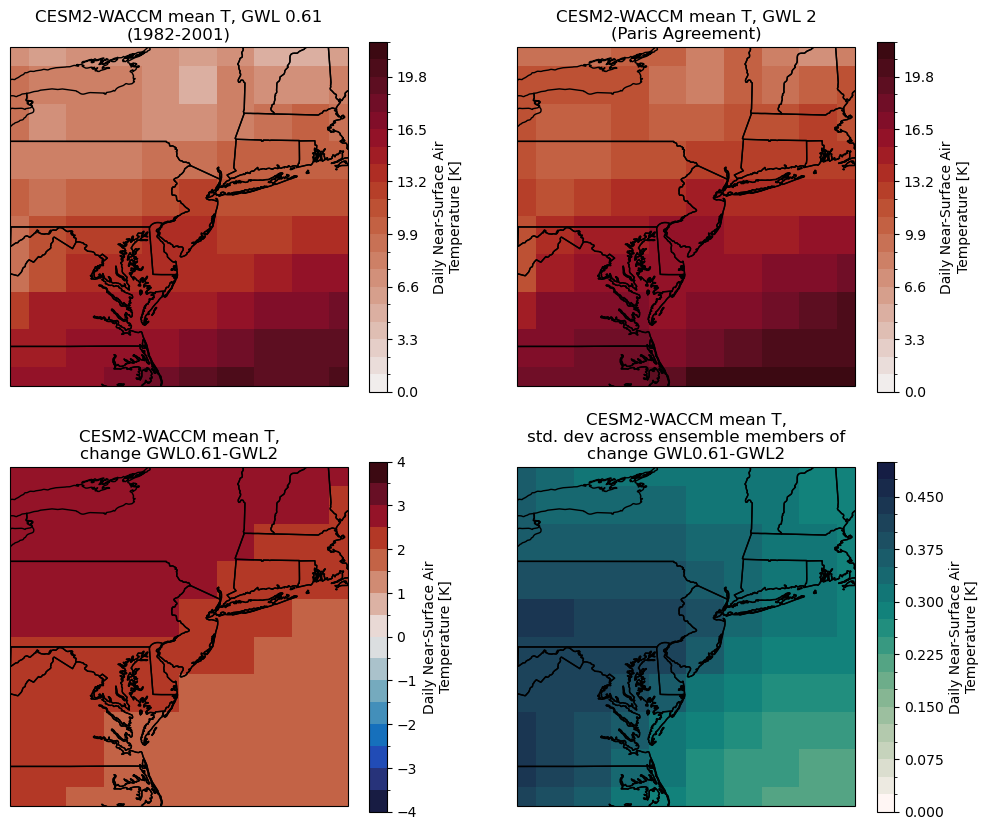

In [119]:
fig = plt.figure(figsize=(12,10))
#------------------------------------------------
# Setup
#------------------------------------------------

ref_gwl = 0.61
fut_gwl = 2

save_figure = True
save_filename = f'{mod}_mean_maps.png'

#------------------------------------------------
# First panel, "GWL0.61", i.e., 1982-2001 in the real world
#------------------------------------------------
ax = plt.subplot(2,2,1,projection=ccrs.PlateCarree())

# Set the data to plot, in this case, teh 20-year average
# temperature, averaged across all runs of the model
plot_data = (
            ds_tmp.
            sel(gwl=ref_gwl). # Select the 0.61 GWL level 
            mean('idv'). # Get mean over different runs of the model
            mean(('dayofyear','year'))  # Get 20-year average
            )

# Now, plot the data 
plot_data.plot(
             cmap=cmocean.cm.amp, # Choose a nice colormap
             vmin=0,vmax=22,levels = 21, # Set colormap limits
             transform=ccrs.PlateCarree(), # Tell the plotting library that the data is in lat/lon format, so it knows how to plot it 
        )

# Add borders, etc. 
ax = plot_annotations(ds_tmp,ax)

ax.set_title(mod+' mean T, GWL 0.61\n(1982-2001)')

#------------------------------------------------
# Second panel, "GWL2", a Paris Agreement world 
#------------------------------------------------
ax = plt.subplot(2,2,2,projection=ccrs.PlateCarree())

# We'll set the plot data as before, but now with GWL = 2
plot_data = (
             ds_tmp.
             sel(gwl=fut_gwl). # Select the 2GWL level 
             mean('idv').mean(('dayofyear','year'))
)

# Plot as before
plot_data.plot(cmap=cmocean.cm.amp,transform=ccrs.PlateCarree(),vmin=0,vmax=22,levels = 21)
# Add borders, etc. 
ax = plot_annotations(ds_tmp,ax)

ax.set_title(mod+' mean T, GWL 2\n(Paris Agreement)')

#------------------------------------------------
# Third panel, change between GWL0.61 and GWL2 
#------------------------------------------------
ax = plt.subplot(2,2,3,projection=ccrs.PlateCarree())
# As before, taking the 20-year mean across different runs
# (but, without selecting a particular GWL)
plot_data = ds_tmp.mean('idv').mean(('dayofyear','year'))
# But now, we'll take the difference between GWLs 0.61 and 2
plot_data = plot_data.sel(gwl=fut_gwl) - plot_data.sel(gwl=ref_gwl)

plot_data.plot(
         cmap=cmocean.cm.balance, # Choose a nice diverging colormap
         vmin=-4,vmax=4,levels=17, # Set colorbar limits to show change
         transform=ccrs.PlateCarree(),
        )

# Add borders, etc. 
ax = plot_annotations(ds_tmp,ax)

ax.set_title(mod+' mean T,\nchange GWL0.61-GWL2')

#------------------------------------------------
# Fourth panel, std. dev of change across  
#------------------------------------------------
ax = plt.subplot(2,2,4,projection=ccrs.PlateCarree())
# Now, taking the mean across years / days of year
plot_data = ds_tmp.mean(('dayofyear','year'))
# Getting the change from one GWL to other
plot_data = plot_data.sel(gwl=fut_gwl) - plot_data.sel(gwl=ref_gwl)
# But taking the standard deviation across the different ensemble members
plot_data = plot_data.std('idv')

plot_data.plot(
         cmap=cmocean.cm.tempo, # Choose a different monotonic colormap
         vmin=0,vmax=0.5,levels=21, # Set colorbar limits to show change
         transform=ccrs.PlateCarree(),
        )

# Add borders, etc. 
ax = plot_annotations(ds_tmp,ax)

ax.set_title(mod+' mean T,\nstd. dev across ensemble members of\nchange GWL0.61-GWL2')


#------------------------------------------------
# Print 
#------------------------------------------------
if save_figure:
    plt.savefig(save_filename)
    print(save_filename+' printed!')

So, we've plotted four things: the average temperature over some historical period (top left), the average temperature projected by this model in a 2-degree world (top right), and the change in temperature between those two periods (bottom left). Now, in all of these three panels, we've been plotting the average across many different runs of this same GCM. The bottom right figure shows the standard deviation of this change across all of these runs.

### Questions

- **1.1 Describe the patterns of warming (their geography, their magnitude) that you see above**. Remember that these local changes are happening between GWLs0.61 and 2, in other words, while the Earth _on average_ is warming ~1.4 degrees Celsius. Is the Northeast warming more or less than the global average?
- **1.2 Describe the pattern of internal variability in this change, based on the bottom right figure**. Remember that each of these GCM runs is interchangeable - all are equally plausible within the model's reality due to the chaos in the system.
- **1.3 What would the information in these figures be useful for?** Are we looking at the right metrics? Is the data of high resolution enough to tell us something about climate risk?

Optionally, let's also think about what this figure would look like if: 
- **1x.1 We analyzed another model?** (pick another model out of the list and regenerate the figure)
- **1x.2 We looked at the hottest day instead of the mean?** (replace `.mean(('dayofyear','year'))` with `.max(('dayofyear','year')` in each figure)
- **1x.3 We looked at a particular day of the year?** (replace `.mean(('dayofyear','year'))` with `.sel(dayofyear=X).mean('year')`, setting `X` to the day number that you'd like, such as `1` for January 1st)

## 2. Diagnostics of extreme changes, in one location

These large-scale changes are not necessarily the right information if we're thinking about local risks from climate change. Let's look instead at something more localized, for example, the number of days where the average temperature is warmer than 85$^\circ$ F / ~25$^\circ$ C, using a _downscaled_ version of the same data. 

There's often a lot of variation in the climate at small scales. Lamont-Doherty Earth Observatory, the Columbia campus where my office is at, usually is cooler in both the winter and summer than the Morningside campus in the city, for example (due to a combination of the heat island effect and being further away from the ocean, which otherwise would moderate its climate in the winter). 

**Downscaling** finds a relationship between the large-scale and the small-scale, using one of many different possible methodologies. Ideally, this results in better representations of topography or land-use driven effects that could affect the climate at local scales. The BCD-ME compares high-resolution historical data with the same data coarsened to a low resolution to train a statistical map that is then applied to the GCM output (using a methodology called "Quantile-Preserving Localized Analogue Downscaling"). We have access to 0.25-degree data (so 4x4 = 16 times the local resolution as the 1-degree data we looked at above). The BCD-ME doesn't currently provide full time series at the 0.25-degree level (due to storage limitations), but it does have statistics of those time series, such as the number of days per year in temperature bins (so, e.g., how many days had temperatures between 75 and 80 degrees in a GCM run).  

In this section, we'll first look at the 0.25-degree data on a regional level, then zoom in onto New York and see how the local exposure to extreme temperatures is projected to change.  

We're also now going to look across multiple models to better understand **model uncertainty** in these projections, in addition to the **internal variability** we looked at in the previous section. 

In [366]:
# Start session to access 0.25-deg downscaled data
repo = client.get_repo("ClimateUncertaintyLab/bcd_me_qdm_qplad")
session = repo.readonly_session(branch="main")

# Get list of available GCMs as a reminder (it's the same one)
modlist = np.sort(list(zarr.open_group(session.store,mode='r').group_keys()))

# there's currently a bug with the data for the GCM EC-Earth3, so I'm going to remove it: 
modlist = [mod for mod in modlist if mod != 'EC-Earth3']

print('Available models: '+', '.join(modlist))

Available models: ACCESS-ESM1-5, CESM2-WACCM, CNRM-CM6-1, CNRM-ESM2-1, CanESM5, EC-Earth3-Veg, FGOALS-g3, IPSL-CM6A-LR, MIROC6, MPI-ESM1-2-LR, MRI-ESM2-0


In [361]:
# Open one model's worth of data 
mod = 'CESM2-WACCM'
print(f'Opening {mod}')
ds = xr.open_zarr(session.store, zarr_format=3, group=mod, decode_timedelta=False)

Opening CESM2-WACCM


As before, we can look at the structure of the data if we wish, by running the cell below. Note that there are several statistics available - bin-days in Fahrenheit and Celsius, and summed polynomials of temperature, which are used in climate econometrics to construct nonlinear models for climate-society interactions. We'll just look at the bin-days today. 

In [362]:
ds

<xarray.Dataset> Size: 764GB
Dimensions:        (idv: 8, proj_base: 4, lat: 142, lon: 360, gwl: 8,
                    dayofyear: 365, year: 20, variable: 1)
Coordinates:
    experiment     (idv) <U6 192B dask.array<chunksize=(8,), meta=np.ndarray>
    model          (idv) <U11 352B dask.array<chunksize=(8,), meta=np.ndarray>
    run            (idv) <U8 256B dask.array<chunksize=(8,), meta=np.ndarray>
  * proj_base      (proj_base) <U6 96B 'ERA5' 'GMFD' 'JRA-3Q' 'MERRA2'
  * lat            (lat) float64 1kB -55.5 -54.5 -53.5 -52.5 ... 83.5 84.5 85.5
  * lon            (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * gwl            (gwl) float64 64B 0.61 1.0 1.5 2.0 2.5 3.0 3.5 4.0
    has_data       (variable, idv, gwl) bool 64B dask.array<chunksize=(1, 8, 8), meta=np.ndarray>
  * dayofyear      (dayofyear) int64 3kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
  * year           (year) int64 160B 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    calendar_year  (idv, gwl, year) float64 10kB dask.array<chunksize=(8, 8, 20), meta=np.ndarray>
  * variable       (variable) object 8B 'tas'
Dimensions without coordinates: idv
Data variables:
    tas            (idv, proj_base, lat, lon, gwl, dayofyear, year) float64 764GB dask.array<chunksize=(1, 1, 40, 40, 1, 365, 20), meta=np.ndarray>
Attributes:
    DESCRIPTION:  CESM2-WACCM ScenarioMIP runs, bias-corrected using Quantile...
    Project:      Bias-Corrected, Downscaled Massive Ensemble (BCD-ME)
    Creators:     Kevin Schwarzwald, Nathan Lenssen, Radley Horton, and Gerno...
    Version:      v1.0
    License:      CC BY 4.0

Let's first confirm that this data is higher resolution. Run the cell below to see a plot of the number of days / year with a mean temperature above 70 $^\circ$F, and note the higher number of grid cells than in the 1-degree data above. Note also that this dataset only has data on grid cells that have land in them, which is fine enough for our purposes (**2x.1 can you think of a climate impact that would require data on ocean grid cells to resolve?**). 

Text(0.5, 1.0, '# of days / year with mean T > 70 at GWL0.61')

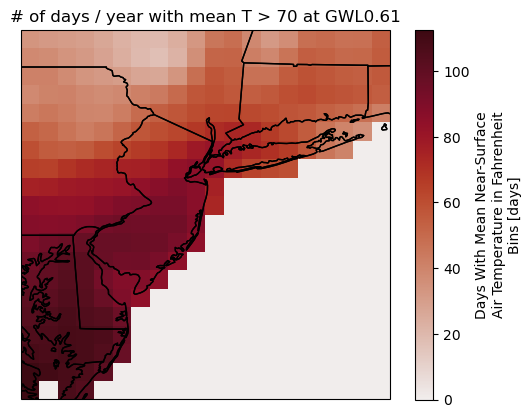

In [206]:
ax = plt.subplot(projection=ccrs.PlateCarree())

ds.sel(lat=slice(37.5,42.5),lon=slice(-76.5,-71.5),
       proj_base='ERA5',gwl=0.61,
       binF=slice(72.5,None)).isel(idv=0).tasbinF.sum('binF').plot(cmap=cmocean.cm.amp,transform=ccrs.PlateCarree())

ax.coastlines()
# Add state boundaries
with warnings.catch_warnings():
    warnings.filterwarnings('ignore')
    np.seterr(invalid='ignore')
    ax.add_feature(cartopy.feature.STATES)

ax.set_title('# of days / year with mean T > 70 at GWL0.61')

From the preview of the dataset, you noticed many different varaibles. For our current purposes, we can ignore most of that and just extract `tasbinF`, the number of days / year in Fahrenheit temperature bins, at New York. 

In [214]:
# New York is at 40.7° N, 74.0° W
location = {'lat':40.7,'lon':-74}
# Let's get the closest model grid cell to that
ds_tmp = ds.sel(**location,method='nearest')
# Let's grab data bias-corrected and downscaled to "ERA5" again
# and once again look at GWLs 0.61 and 2
ds_tmp = ds_tmp.sel(proj_base = 'ERA5',gwl=[0.61,2])
# Finally, let's grab only the tasbinF variable, which 
# gives the number of days per year in fahrenheit bins
ds_tmp = ds_tmp['tasbinF']

In [215]:
# Let's load the data locally
ds_tmp = ds_tmp.load()

Now we will plot a histogram of the number of days / year on average in each temperature bin in the data, for GWL0.61 (the historical period spanning 1982-2001 we looked at before) and the Paris-Agreement-based GWL2. 

Text(0.5, 0, 'Temperature bin [F]')

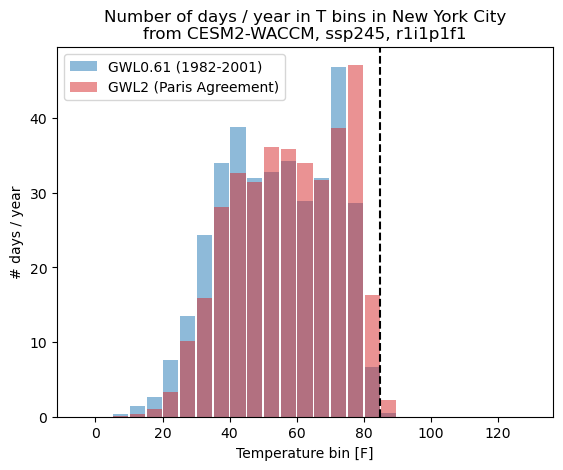

In [216]:
ax = plt.subplot()

# Let's show the change in number of days by bin for the two GWLs we looked at before
plot_data = ds_tmp.isel(idv=0)

plt.bar(plot_data.binF, # Tell matplotlib to put the bars in the middle of each temperature bin
        plot_data.sel(gwl=0.61), # Plot number of days per bin at GWL0.61
        width=4.5,alpha=0.5,color='tab:blue', # Make visually nice (set bar width, make partially transparent, set color)
        label='GWL0.61 (1982-2001)')

plt.bar(plot_data.binF,
        plot_data.sel(gwl=2),
        width=4.5,alpha=0.5,color='tab:red',
        label='GWL2 (Paris Agreement)')
ax.axvline(85,color='k',linestyle='--')

ax.legend()
ax.set_title('Number of days / year in T bins in New York City\n'+
             'from '+', '.join([str(plot_data[v].values) for v in ['model','experiment','run']]))
ax.set_ylabel('# days / year')
ax.set_xlabel('Temperature bin [F]')

Remember that these are days for which the _mean_ temperature (including overnight) is between the bin edges (e.g., 60-65 F). 

### Questions
- **2.1. Describe the differences in heat exposure that this model projects between GWL0.61 and GWL2** (feel free to read off the graph, or, if you feel comfortable, analyze the actual raw values that you can see by printing `plot_data`). 

Remember also that this is what one run of one model says about the future. Let's now look at the same statistic from a range of different runs from different models! The BCD-ME has data for about 300 runs from 12 different GCMs, which should give us a good estimate of the magnitude of internal variability and model uncertainty in projections of exposure to extreme heat (_within the GCM's own realities_ at least). 

To keep it simple, we're going to load just the number of days that are hotter than 85 degrees on average (the dashed line in the figure above). 

In [217]:
# Just some helper code to load data cross 
def subselect_and_load(mod,location = {'lat':40.7,'lon':-74},load_varname='tasbinF'):
    print(f'Processing model {mod}')
    # Load data for desired model    
    ds = xr.open_zarr(session.store, zarr_format=3, group=mod, decode_timedelta=False)

    # Let's get the closest model grid cell to that
    ds_tmp = ds.sel(**location,method='nearest')
    # Let's grab data bias-corrected and downscaled to "ERA5" again
    # and once again look at GWLs 0.61 and 2
    ds_tmp = ds_tmp.sel(proj_base = 'ERA5',gwl=[0.61,2])
    # Finally, let's grab only the tasbinF variable, which 
    # gives the number of days per year in fahrenheit bins
    ds_tmp = ds_tmp[load_varname]

    # Load 
    ds_tmp = ds_tmp.load()

    return ds_tmp

In [219]:
dss = [subselect_and_load(mod) for mod in modlist]

# If you want to try a different location, run this code instead, 
# by removing the "#" comment character at the start of it 
# (and adding a "#" to the `dss = ` line above, so as not to run it):
# dss = [subselect_and_load(mod, location = {'lat':latitude,'lon':longitude}) for mod in modlist]

# 
dss = xr.concat(dss,dim='idv')
dss = dss.dropna('idv',how='any')

Processing model ACCESS-ESM1-5
Processing model CESM2-WACCM
Processing model CNRM-CM6-1
Processing model CNRM-ESM2-1
Processing model CanESM5
Processing model EC-Earth3-Veg
Processing model FGOALS-g3
Processing model IPSL-CM6A-LR
Processing model MIROC6
Processing model MPI-ESM1-2-LR
Processing model MRI-ESM2-0


In [363]:
T_limit = 85
days_above_T = dss.sel(binF = slice(T_limit,None)).sum('binF',skipna=False)

In [364]:
# Let's prepare to plot the difference in days above our desired limit
plot_data = (days_above_T.sel(gwl=2) - days_above_T.sel(gwl=0.61))

Text(0.5, 1.0, 'Change in extreme heat exposure, New York City\nbetween GWLs 0.61 and 2')

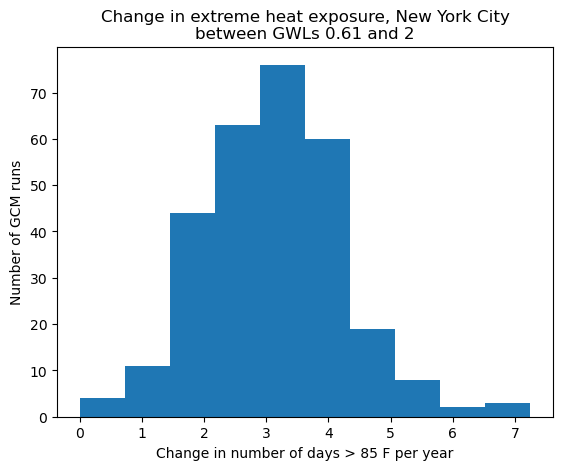

In [365]:
# Let's first look at the change across all model ensembles
ax = plt.subplot()
plot_data.plot.hist()

ax.set_ylabel('Number of GCM runs')
ax.set_xlabel(f'Change in number of days > {str(T_limit)} F per year')
ax.set_title('Change in extreme heat exposure, New York City\nbetween GWLs 0.61 and 2')

The histogram above shows how many GCM runs show a particular change in number of days > 85 F (unless you've changed the threshold, of course). This gives us one idea of the uncertainty in this metric, but note that different models have different number of runs available - so we're over-sampling models that happen to have more data published. 

In [279]:
# This code will generate a useful diagnostic figure below
def plot_model_boxplots(da,
                        title='Change in extreme heat exposure, New York City',
                        xlabel=f'Change in number of days > {str(T_limit)} F per year'):
    
    # Convert to DataFrame
    df = pd.DataFrame({
        'value': da.values,
        'model': da.coords['model'].values,
        'experiment': da.coords['experiment'].values,
    })
    
    models = sorted(df['model'].unique())
    experiments = sorted(df['experiment'].unique())
    n_models = len(models)
    
    # Color palette - one per model
    cmap = plt.cm.tab20
    colors = {m: cmap(i / n_models) for i, m in enumerate(models)}
    
    # Marker shapes per experiment
    markers = {'ssp245':'o',
               'ssp370':'P',
               'ssp585':'^'}
    markers = {**markers,
               **{exp:'D' for exp in experiments if exp not in markers}}
    
    fig, ax = plt.subplots(figsize=(8, n_models * 0.3 + 2))
    
    for i, model in enumerate(models):
        data = df[df['model'] == model]['value'].values
        color = colors[model]
    
        bp = ax.boxplot(
            data,
            positions=[i],
            vert=False,
            widths=0.6,
            patch_artist=True,
            medianprops=dict(color='white', linewidth=2),
            boxprops=dict(facecolor=color, color=color),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
            flierprops=dict(marker='', linestyle='none'),
        )
    
        # Now plot every individual model run's estimate
        for exp in experiments:
            pts = df[(df['model'] == model) & (df['experiment'] == exp)]['value'].values
            np.random.seed(42)
            # Moving the points up and down a random amount so they are 
            # less likely to overlap
            jitter = np.random.uniform(-0.15, 0.15, size=len(pts))
            ax.scatter(pts, i + jitter, marker=markers[exp], color='white',
                      edgecolors=color, s=30, linewidths=0.8, zorder=3)
    
    ax.set_yticks(range(n_models))
    ax.set_yticklabels(models, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('GCM')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    
    # Legend for experiments
    legend_elements = [
        mpatches.Patch(facecolor='none', label=''),  # spacer
        *[plt.Line2D([0], [0], marker=markers[exp], color='grey',
                     label=exp, linestyle='none', markersize=6)
          for exp in experiments]
    ]
    ax.legend(handles=legend_elements[1:], title='Experiment',
              loc='lower right', fontsize=7)
    
    plt.tight_layout()
    return fig, ax

The following code will plot a figure that shows boxplots of the change in number of days > 85 F for each GCM, and also shows where each individual run of each GCM falls within that distribution. 

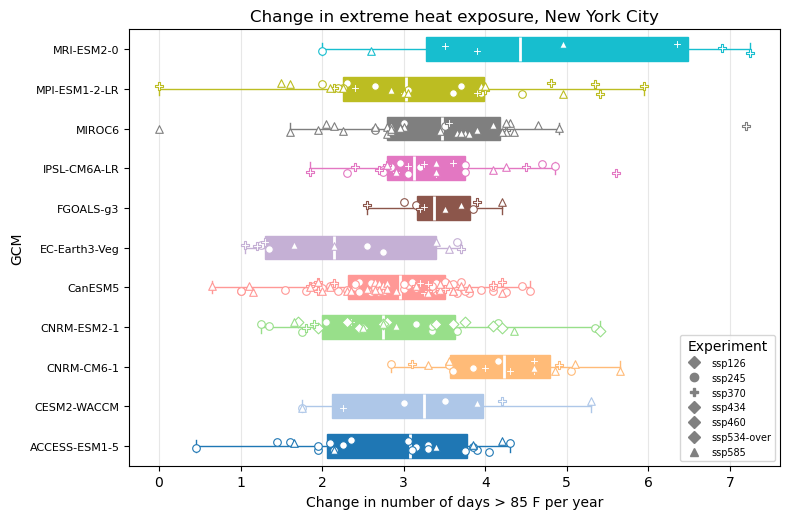

In [280]:
fig,ax = plot_model_boxplots(plot_data)

### Questions
- **2.2. Describe the projected changes in number of days > 85 F in New York City**
- **2.3. Do you think there's more uncertainty from model differences or internal variability in these changes?** (There are [ways](https://esd.copernicus.org/articles/11/491/2020/) of explicitly quantifying this, but for now, feel free to eyeball whether you think more of the spread seen in the histogram figure before this one is coming from differences between the bar plots, or from the range of runs within each of these bar plots. Note also how models with more ensemble members don't necessarily have wider ranges of internal variability, though we are likely estimating that internal variability more accurately with more ensemble members)
- **2.4. If you wanted to constrain the range of model uncertainty, what would you do?** (In other words, are there ways of figuring out which of these models may be more or less trustworthy for the task we are setting them? Think back to your reading and this lecture). **Relatedly, could you better constrain the range of internal variability?** 
- **2.5. Given these projected changes in climate conditions, can you say anything about possible changes in heat-related risk in NYC?**

Here are some more questions to keep in mind when interpreting these GCM results: 
- **2x.1.** Are the models even able to simulate the hottest days in NYC for the 'right' reasons? (your optional reading, [Nissan et al. 2020](https://www.sciencedirect.com/science/article/pii/S2212096320300036), deals with one way to think about this, for example)

## 3. Projections of heat-related mortality changes in New York City

To finalize our risk assessment, we want to translate changes in temperature to a concrete human impact. We'll be using a simple model that relates exposure to days at particular temperatures to total annual mortality. This model was developed by [Deschênes and Greenstone, 2011](https://www.aeaweb.org/articles?id=10.1257/app.3.4.152), and was a groundbreaking work of econometrics when it came out. As you'll see in the diagnostic figure below, the model claims that, as people are exposed to temperatures above or below some optimum temperature, mortality increases. It wasn't necessarily designed for this kind of localized risk assessment; rather, we can think of it as the change in mortality rates that the average American county would experience from a change in temperature exposure, holding all else equal (crucially, this includes no adaptation efforts beyond the original data range of the study, 1968-2002). 

Nevertheless, I've included a little exercise involving this temperature-mortality model because:

1. Its simplicity allows us to work with it in the confines of a single class exercise
2. Its basic form (increased mortality due to too hot and too cold temperatures, with more danger at the high end) has since been confirmed in many different studies in many different contexts
3. Conceptually, it is similar to many other climate risk or climate impacts models, which, though they may have a more complex form or take in more variables, are generally mapping exposure to climate conditions to societal responses

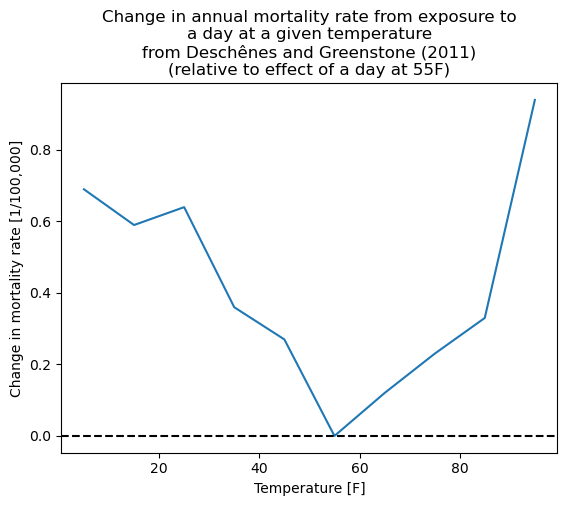

In [336]:
# Damage function, with central values taken from Deschênes and Greenstone Figure 2
damage_function = xr.DataArray([0.69,0.59,0.64,0.36,0.27,0,0.12,0.23,0.33,0.94],dims=['binF'],coords=[np.arange(5,96,10)])

# Let's plot the damage function
ax = plt.subplot()
damage_function.plot()

ax.set_xlabel('Temperature [F]')
ax.set_ylabel('Change in mortality rate [1/100,000]')
ax.set_title('Change in annual mortality rate from exposure to\na day at a given temperature\nfrom Deschênes and Greenstone (2011)\n(relative to effect of a day at 55F)')
ax.axhline(0,color='k',linestyle='--')

Note the basic shape - this model suggests that there's an "ideal" daily mean temperature (somwehere around 55F) for the US, deviations from which result in increases in mortality from any cause (the paper itself suggests cardiac stress as a possible major factor on both the hot or cold end, for example).

**3.1. Knowing what you do about the climate of New York at GWLs 0.61 and 2, (which you looked at above through the barplot histogram figure in Part 2), do you think that the projected temperature increase from GWL0.61 to GWL2 would result in an increase or a decrease in mortality in NYC?**

After you've thought about it for a moment (formulate your hypothesis ahead of time), let's figure out what the combination of the GCMs and this temperature-mortality model actually say!

In [337]:
# The Deschênes and Greenstone model uses days in 10-degree temperature bins
# We'll need to change our data (which is in 5-degree bins) to this format.
# (as part of that, we're cutting off the temperature bins at 90 and 10 F, 
# meaning that all days beyond 10 or 90F are placed in the 10/90 bins. This is
# equivalent to saying that the impact stays constant at higher values than this)
dss_dng = dss.copy()
dss_dng.loc[{'binF':2.5}] = dss_dng.sel(binF = slice(None,2.5)).sum('binF')
dss_dng = dss_dng.sel(binF = slice(2.5,None))
dss_dng = dss_dng.coarsen(binF=2).sum()
dss_dng.loc[{'binF':5}] = dss_dng.sel(binF = slice(None,5)).sum('binF')
dss_dng.loc[{'binF':95}] = dss_dng.sel(binF = slice(95,None)).sum('binF')
dss_dng = dss_dng.sel(binF = slice(5,95))

In [338]:
# Get the change from GWL0.61 to GWL2 in bin-days
change_in_tbins = (dss_dng.sel(gwl=2) - dss_dng.sel(gwl=0.61))

# Translate to change in mortality
change_in_mortality = (change_in_tbins*dmgf).sum('binF')

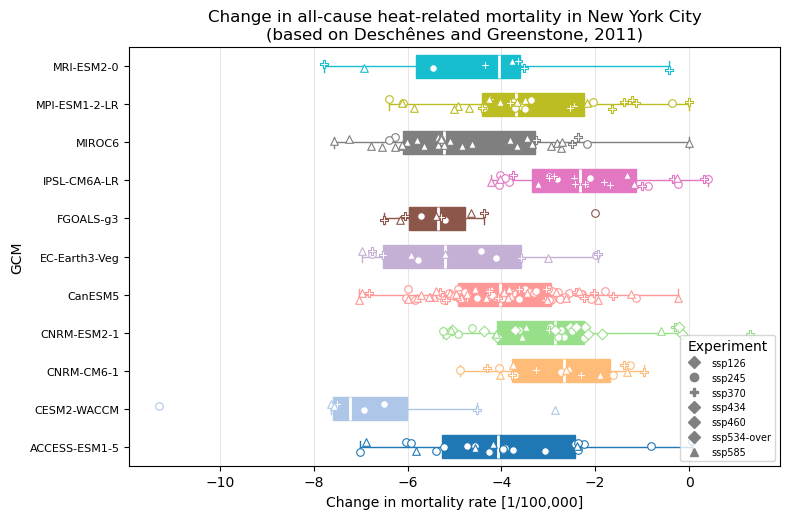

In [341]:
fig,ax = plot_model_boxplots(change_in_mortality,
                             title='Change in all-cause heat-related mortality in New York City\n(based on Deschênes and Greenstone, 2011)',
                             xlabel='Change in mortality rate [1/100,000]')

- **3.2. Did this projected change in mortality rate match up with your expectations set out in 3.1.?**
- **3.3. Does this change your conclusions from 2.5. in any way?** 

#### Some more food for thought: 
Today we're only looking at the uncertainty in the climate data, but climate impact models come with their own uncertainties as well. The standard errors shown in Figure 2 of Deschênes and Greenstone show one of those sources of uncertainty - the statistical uncertainty from fitting their temperature-mortality model. We ignored that in this exercise (though it's possible to incorporate it through, for example, a sampling technique known as Monte Carlo simulations across those error bars). If you're interested in learning more, check out the [Practical Guide to Climate Econometrics](https://climateestimate.net/content/getting-started.html) (full disclosure, that I wrote the climate section a while ago)